**Creating Features**

In [5]:
import pandas as pd
import numpy as np
import sklearn
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [7]:
import lightgbm as lgb

In [8]:
df_no_outliers = pd.read_csv('../data/df_no_outliers.csv')

This step is very broad. You can create as many features as you want. For example, you can add 3 new features that are squared: 'bathrooms_squared', 'bedrooms_squared', ''interest_level_squared'. Plot a correlation matrix with the new features. Are the new features more correlated with the target than the basic features?

In [9]:
df_features = df_no_outliers.copy()

In [10]:
df_features["bathrooms_squared"] = df_features["bathrooms"]**2
df_features["bedrooms_squared"] = df_features["bedrooms"] ** 2
df_features["interest_level_squared"] = df_features["interest_level"] ** 2

In [11]:
df_features.head()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
0,1.0,1,1,2400,1.00,1,1
1,1.0,2,0,3800,1.00,4,0
2,1.0,2,1,3495,1.00,4,1
3,1.5,3,1,3000,2.25,9,1
4,1.0,0,0,2795,1.00,0,0


In [12]:
df_features.corr()

,bathrooms,bedrooms,interest_level,price,bathrooms_squared,bedrooms_squared,interest_level_squared
bathrooms,1.000000,0.517200,-0.062819,0.670808,0.955906,0.548426,-0.058710
bedrooms,0.517200,1.000000,0.051282,0.547310,0.478497,0.928282,0.040125
interest_level,-0.062819,0.051282,1.000000,-0.199652,-0.067757,0.047048,0.943959
price,0.670808,0.547310,-0.199652,1.000000,0.646949,0.544612,-0.182283
bathrooms_squared,0.955906,0.478497,-0.067757,0.646949,1.000000,0.521951,-0.061563
bedrooms_squared,0.548426,0.928282,0.047048,0.544612,0.521951,1.000000,0.036408
interest_level_squared,-0.058710,0.040125,0.943959,-0.182283,-0.061563,0.036408,1.000000


Новые признаки не стали более коррелированными, по сравнению со старыми.

To use PolynomialFeatures, we first need to split the data into training and test samples. We have already done this for you, please read the training and test data.


Initialize PolynomialFeatures() with a degree of 10.


Apply PolynomialFeatures() to fit and transform your training and test data.

In [19]:
from sklearn.preprocessing import PolynomialFeatures

In [21]:
df_train = pd.read_csv("../data/df_no_outliers.csv")
df_train.head()

,bathrooms,bedrooms,interest_level,price
0,1.0,1,1,2400
1,1.0,2,0,3800
2,1.0,2,1,3495
3,1.5,3,1,3000
4,1.0,0,0,2795


In [17]:
df_test = pd.read_json("../data/test.json")
df_test.head()

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address
0,1.0,1,79780be1514f645d7e6be99a3de696c5,2016-06-11 05:29:41,Large with awesome terrace--accessible via bed...,Suffolk Street,"[Elevator, Laundry in Building, Laundry in Uni...",40.7185,7142618,-73.9865,b1b1852c416d78d7765d746cb1b8921f,[https://photos.renthop.com/2/7142618_1c45a2c8...,2950,99 Suffolk Street
1,1.0,2,0,2016-06-24 06:36:34,Prime Soho - between Bleecker and Houston - Ne...,Thompson Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7278,7210040,-74.0000,d0b5648017832b2427eeb9956d966a14,[https://photos.renthop.com/2/7210040_d824cc71...,2850,176 Thompson Street
2,1.0,0,0,2016-06-17 01:23:39,Spacious studio in Prime Location. Cleanbuildi...,Sullivan Street,"[Pre-War, Dogs Allowed, Cats Allowed]",40.7260,7174566,-74.0026,e6472c7237327dd3903b3d6f6a94515a,[https://photos.renthop.com/2/7174566_ba3a35c5...,2295,115 Sullivan Street
3,1.0,2,f9c826104b91d868e69bd25746448c0c,2016-06-21 05:06:02,For immediate access call Bryan.<br /><br />Bo...,Jones Street,"[Hardwood Floors, Dogs Allowed, Cats Allowed]",40.7321,7191391,-74.0028,41735645e0f8f13993c42894023f8e58,[https://photos.renthop.com/2/7191391_8c2f2d49...,2900,23 Jones Street
5,1.0,1,81062936e12ee5fa6cd2b965698e17d5,2016-06-16 07:24:27,Beautiful TRUE 1 bedroom in a luxury building ...,Exchange Place,"[Roof Deck, Doorman, Elevator, Fitness Center,...",40.7054,7171695,-74.0095,a742cf7dd3b2627d83417bc3a1b3ec96,[https://photos.renthop.com/2/7171695_089ffee2...,3254,20 Exchange Place


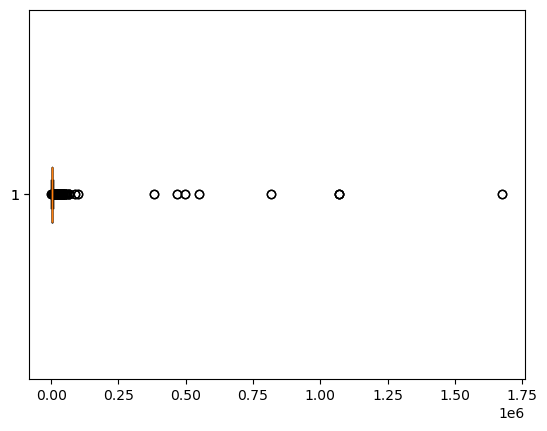

In [26]:
plt.boxplot(df_test["price"], vert = False)
plt.show()

есть выбросы в тестовой выборке, следовательно, нужно и их тоже очистить как и обучающую. удалим 1% и 99% квантили

In [27]:
upper = df_test["price"].quantile(0.99)
lower = df_test["price"].quantile(0.01)

In [28]:
df_test_no_outliers = df_test[(df_test["price"] < upper) & (df_test["price"] > lower)].copy()

In [29]:
df_test_no_outliers.to_csv('../data/df_test_no_outliers.csv', index=False)

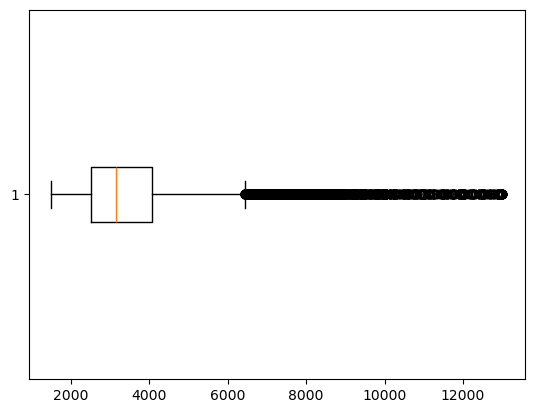

In [30]:
plt.boxplot(df_test_no_outliers["price"], vert = False)
plt.show()

In [32]:
x_train = df_no_outliers[["bathrooms", "bedrooms"]]
y_train = df_no_outliers["price"]

x_test = df_test_no_outliers[['bathrooms','bedrooms']]
y_test = df_test_no_outliers['price']

In [33]:
poly = PolynomialFeatures(degree=10, include_bias=False)

In [34]:
x_train_poly = poly.fit_transform(x_train)
x_test_poly = poly.transform(x_test)